# DSCI 552 HW2

Justin Li

zyli@usc.edu

34004214

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
pd.set_option("display.precision", 4)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")
np.random.seed(42)

## 1(a)

Sheet1 of Folds5x2_pp.xlsx from the UCI repository. The other sheets are shuffled copies of the same data.

In [ ]:
df = pd.read_excel("/Folds5x2_pp.xlsx", sheet_name="Sheet1")
print(df.shape)
df.head()

(9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## 1(b)i Rows and columns

In [ ]:
print(df.dtypes)
print()
print("missing:", df.isna().sum().sum())
print("duplicated rows:", df.duplicated().sum())

AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object

missing: 0
duplicated rows: 41


AT: Ambient temperature (C)

V: Exhaust vacuum (cm Hg)

AP: Ambient pressure (mbar)

RH: Relative humidity (%)

PE: Net hourly electrical output (MW) - Target response

## 1(b)ii Pairwise scatterplots

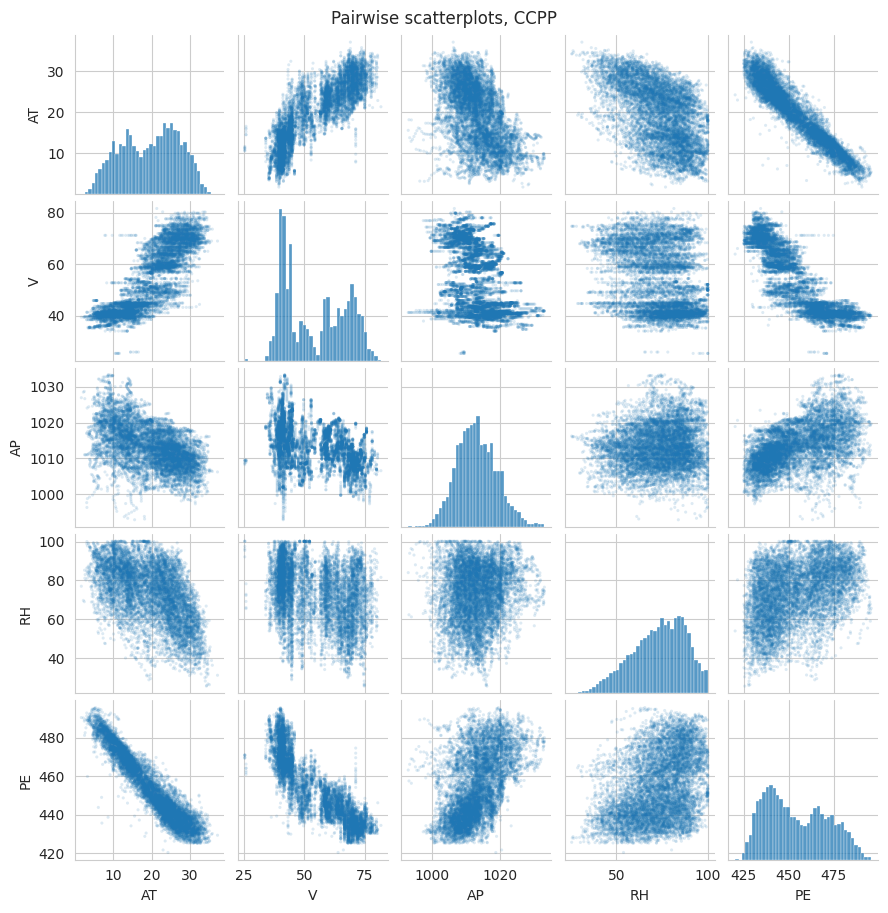

In [ ]:
g = sns.pairplot(df, diag_kind="hist", plot_kws={"s": 5, "alpha": 0.15, "edgecolor": "none"},
                 diag_kws={"bins": 40}, height=1.8)
g.fig.suptitle("Pairwise scatterplots, CCPP", y=1.01)
plt.show()

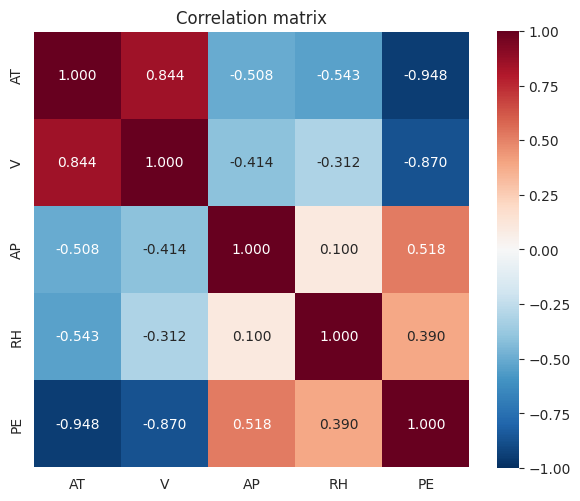

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, fmt=".3f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

AT has a strong negative correlation with PE (r = -0.948), followed by V (r = -0.870). AP (r = 0.518) and RH (r = 0.390) show weaker linear relationships and higher scatter.

The predictors are intercorrelated: AT correlates strongly with V (r = 0.844) and moderately with AP (r = -0.508) and RH (r = -0.543). Scatterplots suggest a very slight curvature for AT and AP.

## 1(b)iii Summary statistics

In [ ]:
summary = pd.DataFrame({
    "mean": df.mean(),
    "median": df.median(),
    "min": df.min(),
    "max": df.max(),
    "range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25),
})
summary.round(3)

,mean,median,min,max,range,Q1,Q3,IQR
AT,19.651,20.345,1.81,37.11,35.30,13.510,25.72,12.210
V,54.306,52.080,25.36,81.56,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,992.89,1033.30,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,25.56,100.16,74.60,63.328,84.83,21.502
PE,454.365,451.550,420.26,495.76,75.50,439.750,468.43,28.680


The predictors have very different scales: AP is around 1013 with an IQR of 8.16, while RH has an IQR of 21.50 and AT has an IQR of 12.21. Due to these scaling differences, features must be standardized before fitting KNN models. The mean and median values are also similar across all variables, suggesting no severe skewness.

## 1(c) Simple linear regression

In [ ]:
preds = ["AT", "V", "AP", "RH"]

simple = {p: smf.ols(f"PE ~ {p}", data=df).fit() for p in preds}

res_c = pd.DataFrame({
    "coef": [simple[p].params[p] for p in preds],
    "std_err": [simple[p].bse[p] for p in preds],
    "t": [simple[p].tvalues[p] for p in preds],
    "p_value": [simple[p].pvalues[p] for p in preds],
    "R2": [simple[p].rsquared for p in preds],
}, index=preds)
res_c

,coef,std_err,t,p_value,R2
AT,-2.1713,0.0074,-291.7152,0.0,0.8989
V,-1.1681,0.0068,-172.4015,0.0,0.7565
AP,1.4899,0.0251,59.2962,0.0,0.2688
RH,0.4557,0.0110,41.3987,0.0,0.1519


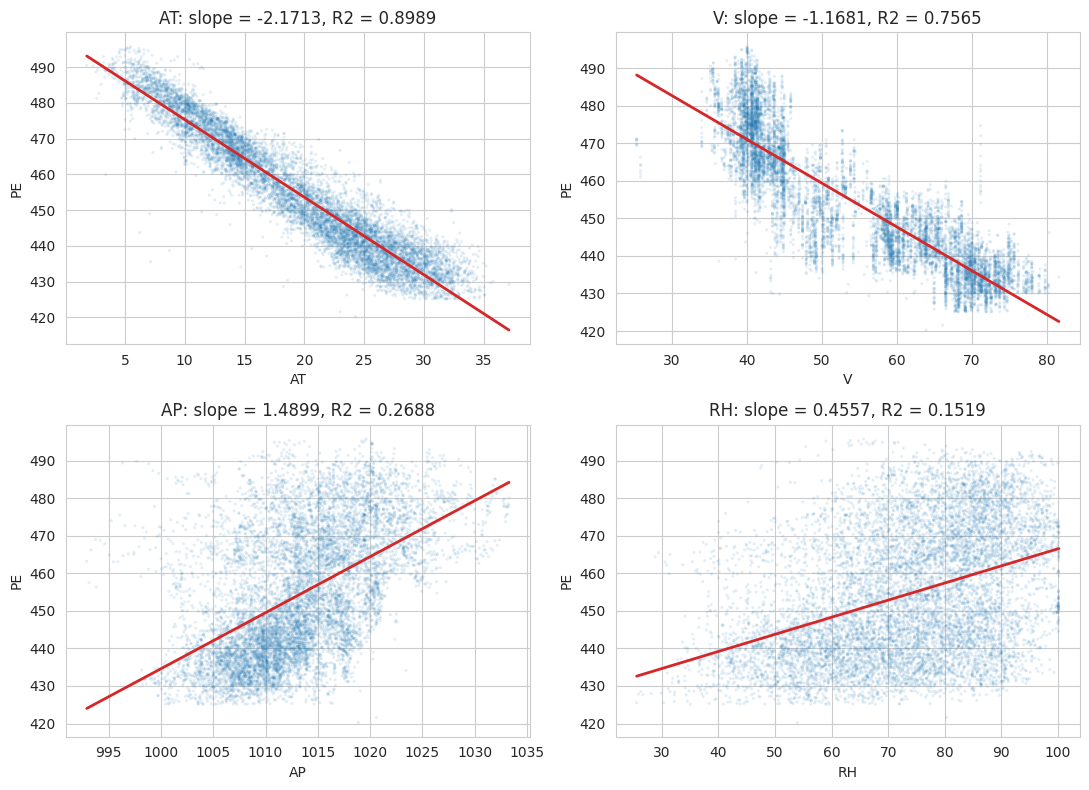

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, p in zip(axes.ravel(), preds):
    ax.scatter(df[p], df["PE"], s=5, alpha=0.12, edgecolor="none")
    xs = np.linspace(df[p].min(), df[p].max(), 200)
    ax.plot(xs, simple[p].predict(pd.DataFrame({p: xs})), color="tab:red", lw=2)
    ax.set_xlabel(p)
    ax.set_ylabel("PE")
    ax.set_title(f"{p}: slope = {simple[p].params[p]:.4f}, R2 = {simple[p].rsquared:.4f}")
plt.tight_layout()
plt.show()

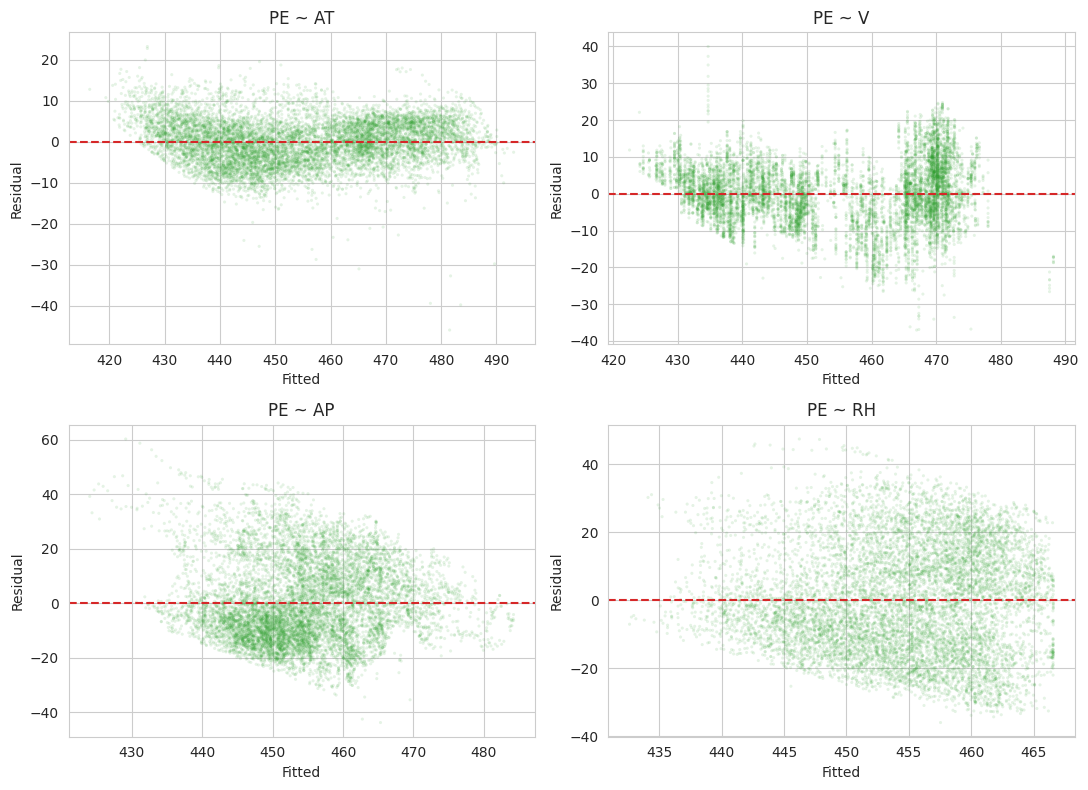

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, p in zip(axes.ravel(), preds):
    ax.scatter(simple[p].fittedvalues, simple[p].resid, s=5, alpha=0.12,
               edgecolor="none", color="tab:green")
    ax.axhline(0, color="tab:red", ls="--")
    ax.set_xlabel("Fitted")
    ax.set_ylabel("Residual")
    ax.set_title(f"PE ~ {p}")
plt.tight_layout()
plt.show()

In [ ]:
rows = []
for p in preds:
    infl = simple[p].get_influence()
    stud = infl.resid_studentized_external
    cooks = infl.cooks_distance[0]
    rows.append({"|stud| > 3": int((np.abs(stud) > 3).sum()),
                 "max |stud|": np.abs(stud).max(),
                 "Cook > 4/n": int((cooks > 4 / len(df)).sum()),
                 "max Cook": cooks.max()})
pd.DataFrame(rows, index=preds)

,|stud| > 3,max |stud|,Cook > 4/n,max Cook
AT,42,8.5024,416,0.0143
V,33,4.7507,423,0.0032
AP,30,4.1337,300,0.0082
RH,2,3.0235,249,0.0021


All four predictors are statistically significant with p-values near 0. AT is the strongest single predictor (R2 = 0.899), followed by V (R2 = 0.757), AP (R2 = 0.269), and RH (R2 = 0.152). AT and V have negative slopes, while AP and RH have positive slopes.

The residual plots for AT and AP show clear curvature, indicating a non-linear relationship. The maximum Cook's distance is 0.0143, which is below the standard threshold of 1.0, indicating no highly influential points.

## 1(d) Multiple regression

In [ ]:
multi = smf.ols("PE ~ AT + V + AP + RH", data=df).fit()
print(multi.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:29:28   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

In [ ]:
X = sm.add_constant(df[preds])
pd.DataFrame({"VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]},
             index=X.columns).round(3)

,VIF
const,1.000
AT,5.978
V,3.943
AP,1.453
RH,1.705


All four predictors remain highly significant (p-values near 0) in the multiple regression model. The overall model is significant (F-statistic = 31140) with an R2 of 0.929.

Collinearity doesn't seem like a major issue as all VIF values are low: AT (5.98), V (3.94), AP (1.45), and RH (1.71). The high condition number flagged in the summary is a scaling artifact caused by the large scale of AP relative to the other variables.

## 1(e) Univariate versus multiple coefficients

In [ ]:
cmp = pd.DataFrame({
    "simple_1c": [simple[p].params[p] for p in preds],
    "multiple_1d": [multi.params[p] for p in preds],
}, index=preds)
cmp["change"] = cmp["multiple_1d"] - cmp["simple_1c"]
cmp

,simple_1c,multiple_1d,change
AT,-2.1713,-1.9775,0.1938
V,-1.1681,-0.2339,0.9342
AP,1.4899,0.0621,-1.4278
RH,0.4557,-0.1581,-0.6137


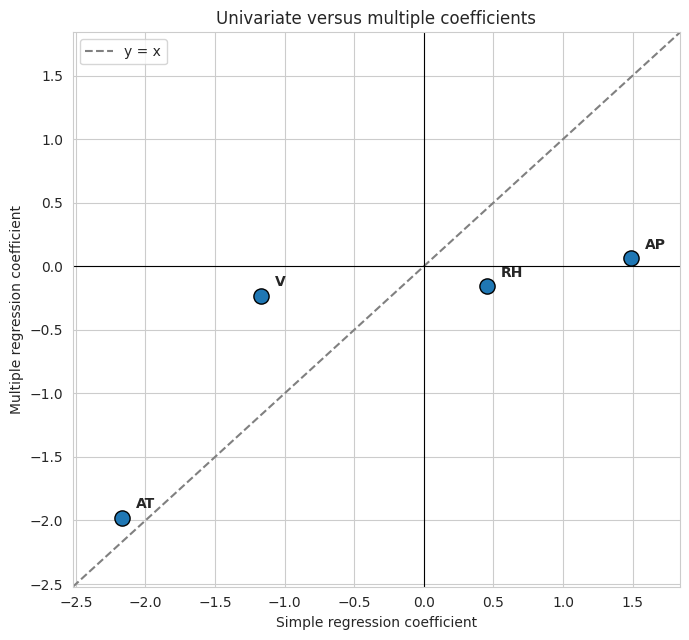

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6.5))
xs, ys = cmp["simple_1c"].values, cmp["multiple_1d"].values
ax.scatter(xs, ys, s=120, zorder=3, edgecolor="black")
for p, x, y in zip(preds, xs, ys):
    ax.annotate(p, (x, y), textcoords="offset points", xytext=(10, 7), fontweight="bold")
lo, hi = min(xs.min(), ys.min()) - 0.35, max(xs.max(), ys.max()) + 0.35
ax.plot([lo, hi], [lo, hi], ls="--", color="gray", label="y = x")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Simple regression coefficient")
ax.set_ylabel("Multiple regression coefficient")
ax.set_title("Univariate versus multiple coefficients")
ax.legend()
plt.tight_layout()
plt.show()

All coefficients change when moving from simple to multiple regression.

Notably, the coefficient for RH flips from positive (+0.4557) to negative (-0.1581). This occurs because RH is negatively correlated with AT (the dominant driver). In simple regression, RH captured this temperature effect. Similarly, the coefficients for AP and V shrink considerably because multiple regression controls for the other correlated predictors.

## 1(f) Nonlinear association

In [ ]:
dfc = df.copy()
for p in preds:
    dfc[p + "_c"] = df[p] - df[p].mean()

cubic, rows = {}, []
for p in preds:
    c = p + "_c"
    lin = smf.ols(f"PE ~ {c}", data=dfc).fit()
    cub = smf.ols(f"PE ~ {c} + I({c}**2) + I({c}**3)", data=dfc).fit()
    cubic[p] = cub
    F, pv, _ = cub.compare_f_test(lin)
    rows.append({"R2_linear": lin.rsquared, "R2_cubic": cub.rsquared,
                 "p_X2": cub.pvalues[f"I({c} ** 2)"], "p_X3": cub.pvalues[f"I({c} ** 3)"],
                 "F": F, "p_F": pv})
pd.DataFrame(rows, index=preds)

,R2_linear,R2_cubic,p_X2,p_X3,F,p_F
AT,0.8989,0.9119,3.3118e-231,3.6522e-110,701.9673,3.4784e-285
V,0.7565,0.7750,8.9770e-131,1.3735e-02,393.3141,7.0403e-165
AP,0.2688,0.2975,2.1927e-46,2.1233e-67,195.8856,4.2091e-84
RH,0.1519,0.1537,1.0139e-01,1.4403e-05,10.1889,3.7996e-05


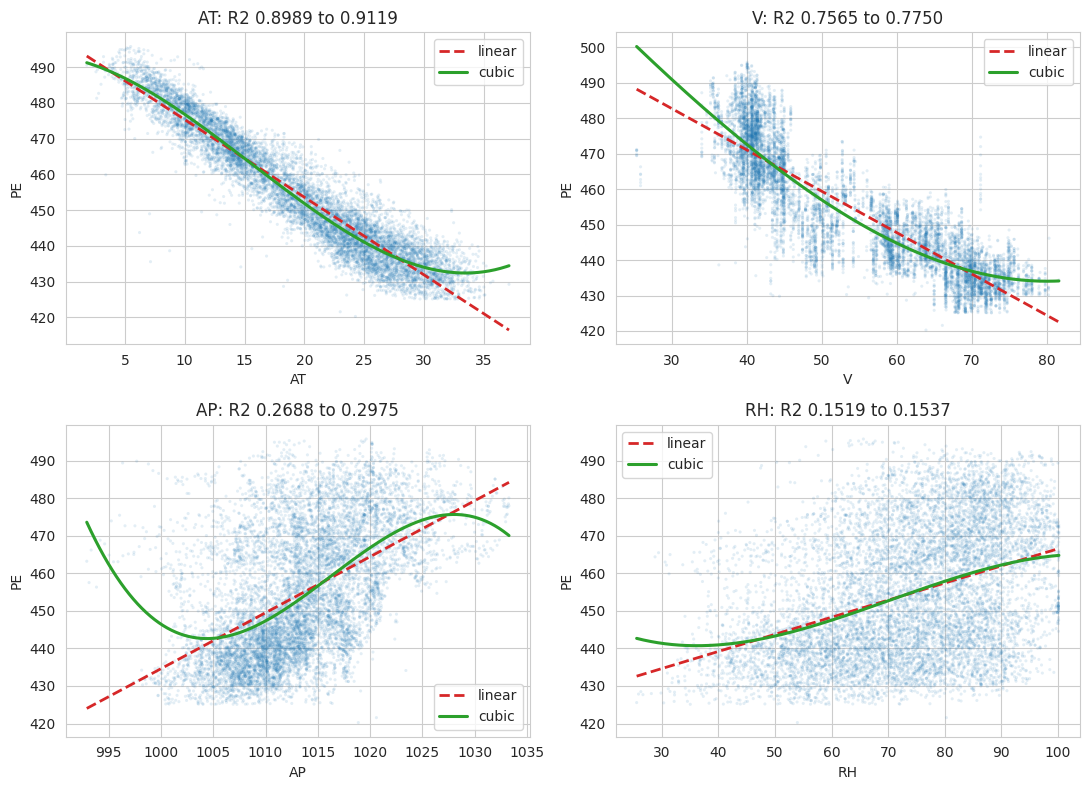

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, p in zip(axes.ravel(), preds):
    c = p + "_c"
    ax.scatter(df[p], df["PE"], s=5, alpha=0.12, edgecolor="none")
    xs = np.linspace(df[p].min(), df[p].max(), 300)
    grid = pd.DataFrame({c: xs - df[p].mean()})
    lin = smf.ols(f"PE ~ {c}", data=dfc).fit()
    ax.plot(xs, lin.predict(grid), color="tab:red", ls="--", lw=2, label="linear")
    ax.plot(xs, cubic[p].predict(grid), color="tab:green", lw=2.2, label="cubic")
    ax.set_xlabel(p)
    ax.set_ylabel("PE")
    ax.set_title(f"{p}: R2 {lin.rsquared:.4f} to {cubic[p].rsquared:.4f}")
    ax.legend()
plt.tight_layout()
plt.show()

The F-test rejects the linear null hypothesis in favor of the cubic model for all four predictors.

AT shows the largest improvement, with R2 increasing from 0.8989 to 0.9119, confirming the non-linear S-curve relationship. AP and V also show modest R2 improvements. While RH is statistically significant due to the large sample size, its practical improvement in R2 is negligible (0.0018).

## 1(g) Interactions

In [ ]:
inter = smf.ols("PE ~ (AT + V + AP + RH)**2", data=df).fit()
print(inter.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:29:30   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [ ]:
terms = [t for t in inter.params.index if ":" in t]
res_g = pd.DataFrame({
    "coef": [inter.params[t] for t in terms],
    "p_value": [inter.pvalues[t] for t in terms],
    "significant": [inter.pvalues[t] < 0.05 for t in terms],
}, index=terms)
F, pv, _ = inter.compare_f_test(multi)
print(f"R2 without interactions: {multi.rsquared:.4f}")
print(f"R2 with interactions:    {inter.rsquared:.4f}")
print(f"partial F = {F:.3f}, p = {pv:.4g}")
res_g

R2 without interactions: 0.9287
R2 with interactions:    0.9363
partial F = 190.299, p = 8.064e-230


,coef,p_value,significant
AT:V,0.0210,3.3334e-117,True
AT:AP,0.0018,4.5205e-01,False
AT:RH,-0.0052,1.2169e-10,True
V:AP,0.0068,2.8770e-07,True
V:RH,0.0008,8.6194e-02,False
AP:RH,-0.0016,3.3606e-02,True


Four of the six pairwise interactions are statistically significant at the 0.05 level. A partial F-test confirms that the interaction model significantly improves upon the main-effects model (p near 0), though the overall R2 only increases by 0.007.

## 1(h) Train/test split and model selection

I'm using a 70/30 train/test split to test each model. Model 1 contains only the linear terms; model 2 contains all main effects, pairwise interactions, and quadratic terms; model 3 is a reduced version of model 2 obtained via backward selection while respecting the existing hierarchy rules.

In [ ]:
train, test = train_test_split(dfc, test_size=0.3, random_state=42)
print("train:", train.shape, " test:", test.shape)

train: (6697, 9)  test: (2871, 9)


In [ ]:
def mse_row(model, name, tr, te):
    a = mean_squared_error(tr["PE"], model.predict(tr))
    b = mean_squared_error(te["PE"], model.predict(te))
    return {"model": name, "terms": len(model.params) - 1, "train_MSE": a,
            "test_MSE": b, "test_RMSE": np.sqrt(b), "adj_R2": model.rsquared_adj}


m1 = smf.ols("PE ~ AT + V + AP + RH", data=train).fit()
r1 = mse_row(m1, "1. linear", train, test)

full = "PE ~ (AT_c + V_c + AP_c + RH_c)**2 + I(AT_c**2) + I(V_c**2) + I(AP_c**2) + I(RH_c**2)"
m2 = smf.ols(full, data=train).fit()
r2 = mse_row(m2, "2. interactions + quadratics", train, test)
print("condition number:", round(m2.condition_number, 1))
print(m2.summary().tables[1])

condition number: 908.5
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      453.1818      0.117   3866.490      0.000     452.952     453.412
AT_c            -1.8176      0.020    -92.049      0.000      -1.856      -1.779
V_c             -0.2962      0.009    -32.516      0.000      -0.314      -0.278
AP_c             0.1165      0.012      9.806      0.000       0.093       0.140
RH_c            -0.1251      0.005    -24.420      0.000      -0.135      -0.115
AT_c:V_c         0.0095      0.003      2.949      0.003       0.003       0.016
AT_c:AP_c        0.0046      0.004      1.291      0.197      -0.002       0.011
AT_c:RH_c       -0.0053      0.002     -2.963      0.003      -0.009      -0.002
V_c:AP_c         0.0015      0.002      0.876      0.381      -0.002       0.005
V_c:RH_c        -0.0001      0.001     -0.167      0.867      -0.002       0.001
AP_c

In [ ]:
def backward(data, terms, alpha=0.05):
    terms = list(terms)
    while True:
        m = smf.ols("PE ~ " + " + ".join(terms), data=data).fit()
        p = m.pvalues.drop("Intercept")
        protected = set()
        for t in terms:
            if ":" in t:
                protected.update(t.split(":"))
            elif t.startswith("I(") and "**" in t:
                protected.add(t[2:t.index("**")])
        removable = {k: v for k, v in p.items()
                     if not (k in protected and ":" not in k and not k.startswith("I("))}
        if not removable:
            return m, terms
        worst = max(removable, key=removable.get)
        if removable[worst] <= alpha:
            return m, terms
        print(f"drop {worst:16s} p = {removable[worst]:.4f}")
        terms.remove(worst)


all_terms = [t for t in m2.params.index if t != "Intercept"]
m3, kept = backward(train, all_terms)
r3 = mse_row(m3, "3. reduced", train, test)
print()
print("kept:", kept)

drop V_c:RH_c         p = 0.8674
drop I(V_c ** 2)      p = 0.6077
drop V_c:AP_c         p = 0.3578

kept: ['AT_c', 'V_c', 'AP_c', 'RH_c', 'AT_c:V_c', 'AT_c:AP_c', 'AT_c:RH_c', 'AP_c:RH_c', 'I(AT_c ** 2)', 'I(AP_c ** 2)', 'I(RH_c ** 2)']


In [ ]:
mse_table = pd.DataFrame([r1, r2, r3]).set_index("model")
mse_table.round(4)

,terms,train_MSE,test_MSE,test_RMSE,adj_R2
model,,,,,
1. linear,4,20.5808,21.2399,4.6087,0.9291
2. interactions + quadratics,14,17.8878,18.6473,4.3183,0.9383
3. reduced,11,17.8908,18.6600,4.3197,0.9383


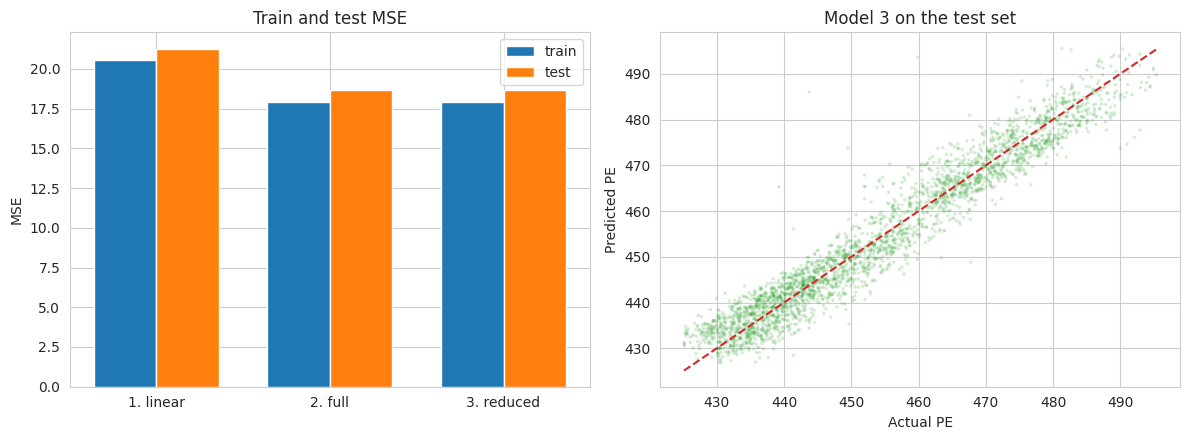

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(3)
axes[0].bar(x - 0.18, mse_table["train_MSE"], 0.36, label="train")
axes[0].bar(x + 0.18, mse_table["test_MSE"], 0.36, label="test")
axes[0].set_xticks(x)
axes[0].set_xticklabels(["1. linear", "2. full", "3. reduced"])
axes[0].set_ylabel("MSE")
axes[0].set_title("Train and test MSE")
axes[0].legend()

axes[1].scatter(test["PE"], m3.predict(test), s=6, alpha=0.2, edgecolor="none", color="tab:green")
lims = [test["PE"].min(), test["PE"].max()]
axes[1].plot(lims, lims, ls="--", color="tab:red")
axes[1].set_xlabel("Actual PE")
axes[1].set_ylabel("Predicted PE")
axes[1].set_title("Model 3 on the test set")
plt.tight_layout()
plt.show()

Model 2 and model 3 outperform model 1, reducing test MSE by approximately 12.2% (test RMSE decreases from 4.61 to 4.32).

Backward selection dropped the interactions and quadratic terms involving V (specifically V_c:RH_c, I(V_c**2), and V_c:AP_c), indicating V behaves linearly once AT is in the model.

There is no sign of overfitting as the gap between train and test MSE remains very small for all models. Model 3 is preferred over Model 2 because it achieves virtually identical performance with three fewer parameters.

## 1(i) KNN regression

In [ ]:
Xtr_raw, ytr = train[preds].values, train["PE"].values
Xte_raw, yte = test[preds].values, test["PE"].values
scaler = StandardScaler().fit(Xtr_raw)
Xtr_s, Xte_s = scaler.transform(Xtr_raw), scaler.transform(Xte_raw)

ks = list(range(1, 101))


def knn_sweep(A, ytr, B, yte, ks):
    tr, te = [], []
    for k in ks:
        m = KNeighborsRegressor(n_neighbors=k).fit(A, ytr)
        tr.append(mean_squared_error(ytr, m.predict(A)))
        te.append(mean_squared_error(yte, m.predict(B)))
    return np.array(tr), np.array(te)


raw_tr, raw_te = knn_sweep(Xtr_raw, ytr, Xte_raw, yte, ks)
nrm_tr, nrm_te = knn_sweep(Xtr_s, ytr, Xte_s, yte, ks)

k_raw = ks[int(np.argmin(raw_te))]
k_nrm = ks[int(np.argmin(nrm_te))]
print(f"raw:        k* = {k_raw}, test MSE = {raw_te.min():.4f}")
print(f"normalized: k* = {k_nrm}, test MSE = {nrm_te.min():.4f}")

raw:        k* = 5, test MSE = 15.7268
normalized: k* = 4, test MSE = 14.3057


In [ ]:
knn_table = pd.DataFrame({"k": ks, "1/k": [1 / k for k in ks], "raw_train": raw_tr,
                          "raw_test": raw_te, "norm_train": nrm_tr, "norm_test": nrm_te})
knn_table[knn_table["k"].isin([1, 2, 3, 4, 5, 7, 10, 15, 20, 30, 50, 75, 100])].round(4)

,k,1/k,raw_train,raw_test,norm_train,norm_test
0,1,1.0000,0.0000,20.3325,0.0000,18.6249
1,2,0.5000,5.5005,17.3441,5.2763,15.4960
2,3,0.3333,8.1266,16.3388,7.3007,14.6332
3,4,0.2500,9.4447,15.8108,8.5914,14.3057
4,5,0.2000,10.6008,15.7268,9.7173,14.6599
6,7,0.1429,11.9838,15.8426,11.2246,14.6610
9,10,0.1000,13.5418,16.3351,12.5772,14.9387
14,15,0.0667,15.0659,16.7930,13.9149,15.6232
19,20,0.0500,16.0830,17.3739,14.7747,15.8974
29,30,0.0333,17.4555,18.0189,16.0367,16.6533


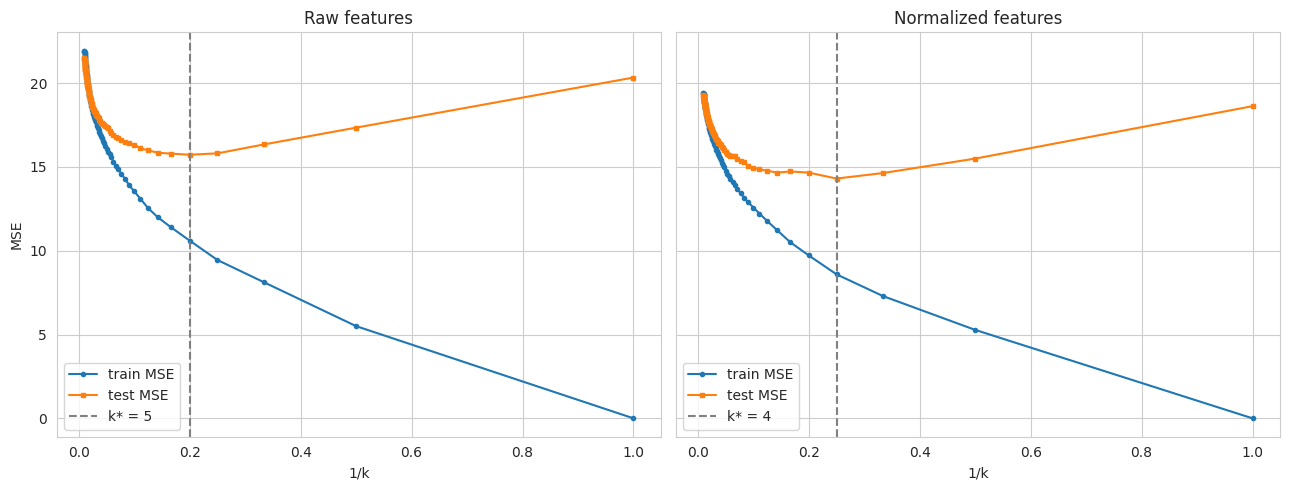

In [ ]:
inv = 1 / np.array(ks)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (tr, te, kb, name) in zip(axes, [(raw_tr, raw_te, k_raw, "Raw"),
                                         (nrm_tr, nrm_te, k_nrm, "Normalized")]):
    ax.plot(inv, tr, "o-", ms=3, label="train MSE")
    ax.plot(inv, te, "s-", ms=3, label="test MSE")
    ax.axvline(1 / kb, color="gray", ls="--", label=f"k* = {kb}")
    ax.set_xlabel("1/k")
    ax.set_title(f"{name} features")
    ax.legend()
axes[0].set_ylabel("MSE")
plt.tight_layout()
plt.show()

The optimal parameter is k = 5 for unscaled features (test MSE = 15.7268) and k = 4 for normalized features (test MSE = 14.3057).

Standardization improves performance across all values of k because it prevents features with larger raw ranges from dominating the distance metric. Both models show a typical bias-variance trade-off curve: training MSE is 0 at k = 1 and increases as k grows, while test MSE shows a U-shape, minimizing at small values of k (3 to 7).

## 1(j) KNN versus linear regression

In [ ]:
final = pd.DataFrame([
    {"method": "linear, predictors only", "test_MSE": r1["test_MSE"]},
    {"method": "linear, interactions + quadratics", "test_MSE": r2["test_MSE"]},
    {"method": "linear, reduced", "test_MSE": r3["test_MSE"]},
    {"method": f"KNN raw, k = {k_raw}", "test_MSE": raw_te.min()},
    {"method": f"KNN normalized, k = {k_nrm}", "test_MSE": nrm_te.min()},
]).set_index("method").sort_values("test_MSE")
final["test_RMSE"] = np.sqrt(final["test_MSE"])

best_lin = mse_table["test_MSE"].min()
print(f"best linear test MSE: {best_lin:.4f}")
print(f"best KNN test MSE:    {nrm_te.min():.4f}")
print(f"improvement: {100 * (best_lin - nrm_te.min()) / best_lin:.1f}%")
final.round(4)

best linear test MSE: 18.6473
best KNN test MSE:    14.3057
improvement: 23.3%


,test_MSE,test_RMSE
method,,
"KNN normalized, k = 4",14.3057,3.7823
"KNN raw, k = 5",15.7268,3.9657
"linear, interactions + quadratics",18.6473,4.3183
"linear, reduced",18.6600,4.3197
"linear, predictors only",21.2399,4.6087


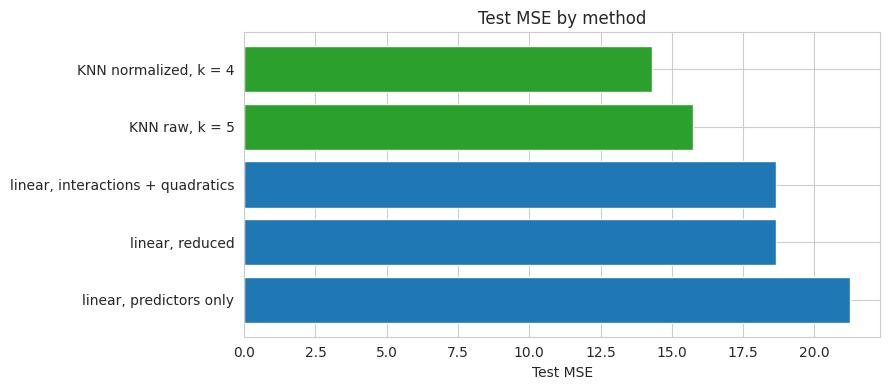

In [ ]:
plt.figure(figsize=(9, 4))
colors = ["tab:green" if "KNN" in m else "tab:blue" for m in final.index]
plt.barh(range(len(final)), final["test_MSE"], color=colors)
plt.yticks(range(len(final)), final.index)
plt.gca().invert_yaxis()
plt.xlabel("Test MSE")
plt.title("Test MSE by method")
plt.tight_layout()
plt.show()

The normalized KNN with k = 4 yields the lowest test MSE (14.3057), a 23.3% improvement over the best quadratic linear model (18.6473).

KNN performs well here because the dataset is large relative to the low dimensionality, which eliminates the curse of dimensionality. However, the linear model remains highly valuable for interpretability, hypothesis testing, computational efficiency, and extrapolation.

## 2. ISLR 2.4.1

(a) n is large, p is small: A flexible method is better. The large sample size keeps model variance low, allowing us to capture complex relationships without overfitting. A rigid model would suffer from high bias that does not decrease with sample size.

(b) p is large, n is small: A flexible method is worse. With few observations and many features, a flexible model will overfit the noise in the training data, leading to extremely high test variance. A rigid model serves as a form of regularization to keep variance low.

(c) The relationship is highly non-linear: A flexible method is better. A rigid model cannot adapt to highly non-linear structures, resulting in high systematic bias. A flexible model can fit the non-linear shape, which reduces test error as long as there is enough data to estimate it.

(d) The variance of the error term is high: A flexible method is worse. High noise means the observations contain little signal. A flexible model will overfit this noise and introduce high variance, whereas a rigid method will average out the noise.

## 3. ISLR 2.4.7

In [ ]:
islr = pd.DataFrame({
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"],
}, index=pd.Index([1, 2, 3, 4, 5, 6], name="Obs"))

islr["distance"] = np.sqrt((islr[["X1", "X2", "X3"]] ** 2).sum(axis=1))
islr["rank"] = islr["distance"].rank().astype(int)
islr.sort_values("distance")

,X1,X2,X3,Y,distance,rank
Obs,,,,,,
5,-1,0,1,Green,1.4142,1
6,1,1,1,Red,1.7321,2
2,2,0,0,Red,2.0000,3
4,0,1,2,Green,2.2361,4
1,0,3,0,Red,3.0000,5
3,0,1,3,Red,3.1623,6


3(a). Euclidean distances to the origin (0,0,0):

Obs 1: d = 3.000 (Rank 5)
Obs 2: d = 2.000 (Rank 3)
Obs 3: d = 3.162 (Rank 6)
Obs 4: d = 2.236 (Rank 4)
Obs 5: d = 1.414 (Rank 1)
Obs 6: d = 1.732 (Rank 2)

3(b). For K = 1, the nearest neighbor is Observation 5, which is Green.

3(c). For K = 3, the three nearest neighbors are Obs 5 (Green), Obs 6 (Red), and Obs 2 (Red). The majority vote is Red (2/3 probability), so the prediction is Red.

3(d). If the true decision boundary is highly non-linear, the best value for K is small. Small K values provide high model flexibility, allowing the decision boundary to capture intricate, non-linear shapes. Large K values smooth the boundary and behave more linearly, which would result in high bias.